# DAY 19: study Attention mechanism — read the Transformer paper, visualize attention heads

### Attention Mechanism and Transformer Architecture

## Objective

The objective of this notebook is to understand:

- Why attention was introduced
- Limitations of RNNs and LSTMs
- Query, Key, and Value concepts
- Self-Attention mechanism
- Multi-Head Attention
- Transformer architecture
- Attention visualization

Attention is one of the most important concepts in modern Natural Language Processing and forms the foundation of Transformer-based models such as BERT, GPT, T5, LLaMA, Gemini, and most modern NLP models.

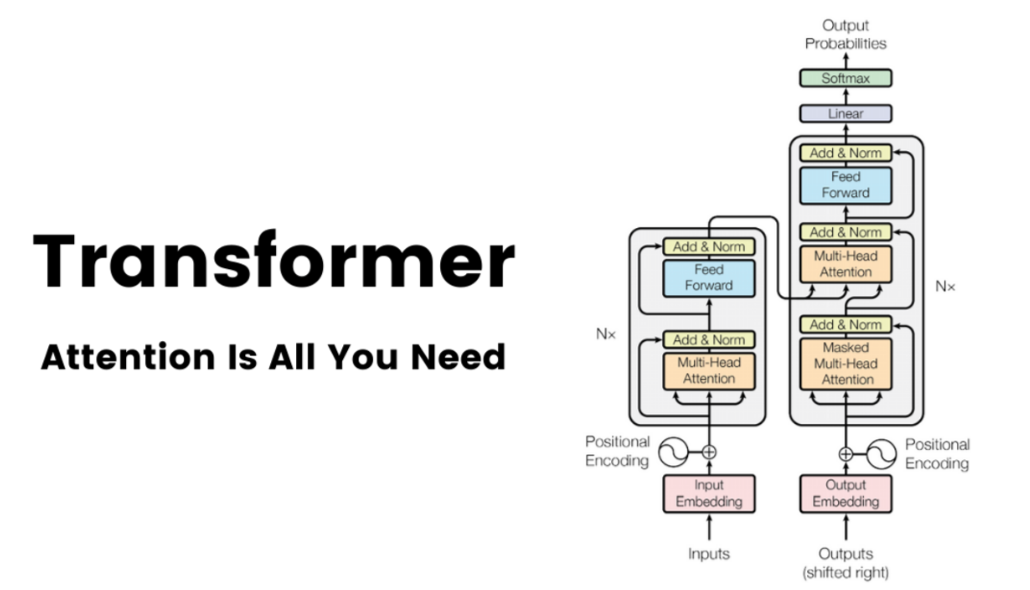

# Why Were RNNs and LSTMs Not Enough?

RNNs process sequences one token at a time.

Although LSTMs improved memory handling, they still have limitations:

- Sequential computation is slow
- Long sequences remain challenging
- Information from distant words may weaken

Example:

"The food at the restaurant that we visited last month was amazing."

To understand the word "amazing", the model may need information from words much earlier in the sentence.

Attention was introduced to allow the model to directly focus on relevant words regardless of their distance.

# Intuition Behind Attention

Instead of remembering everything in a hidden state, attention allows a model to look back at the entire sequence.

When processing a word, the model can decide:

"Which words are most important for understanding this word?"

The model assigns importance scores called attention weights.

Higher weights indicate greater importance.

#  Understanding Attention Weights with simple example

Suppose we have the sentence:

"The cat sat on the mat"

When processing the word "sat", some words may be more important than others.

Attention assigns a weight to each word.

In [1]:
words = ["The", "cat", "sat", "on", "the", "mat"]

attention_scores = [0.05, 0.35, 0.40, 0.10, 0.03, 0.07]

for word, score in zip(words, attention_scores):
    print(f"{word}: {score}")

The: 0.05
cat: 0.35
sat: 0.4
on: 0.1
the: 0.03
mat: 0.07


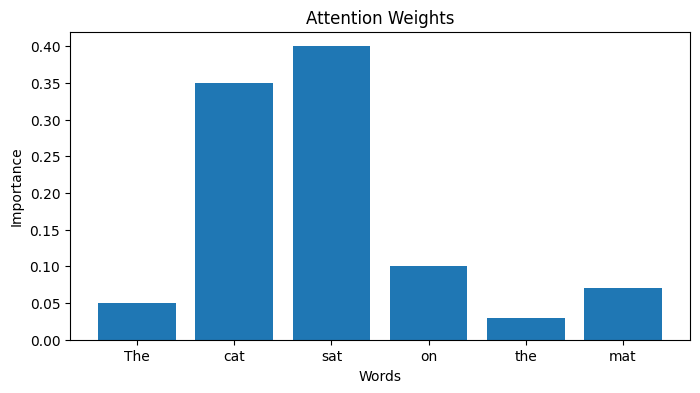

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(words, attention_scores)

plt.title("Attention Weights")
plt.xlabel("Words")
plt.ylabel("Importance")

plt.show()

This is a **simple attention weight visualization** for the sentence "The cat sat on the mat".

**What the graph shows:**
- **X-axis**: Individual words from the sentence
- **Y-axis**: Attention weight/importance score (ranges from 0 to 1)
- **Bar heights**: Represent how much "attention" is paid to each word

**Interpretation:**
- "**sat**" has the highest weight (0.40) - most important word
- "**cat**" has the second-highest weight (0.35) - also very important  
- "**on**" has medium weight (0.10)
- "**The**" and "**the**" have very low weights (0.05, 0.03) - less important
- "**mat**" has minimal weight (0.07)

**Why this matters:**
This demonstrates the core idea of attention: **not all words are equally important**. When the model processes a sentence, it learns which words are most relevant for understanding the context. Words like "sat" and "cat" (the action and the subject) are more important than articles like "the".

Observation:

The highest attention is assigned to:

- cat
- sat

This indicates that these words contribute most to understanding the sentence.

# Query, Key, and Value Intuition

Attention relies on three vectors:

1. Query (Q)
2. Key (K)
3. Value (V)

Think of it like a search engine.

Query:
What information am I looking for?

Key:
What information does each word contain?

Value:
Actual information carried by the word.

The model compares queries with keys to determine which values should receive attention.

# Simple Query-Key Similarity

In [3]:
import numpy as np

query = np.array([1, 0])

keys = np.array([
    [1,0],
    [0,1],
    [1,1]
])

scores = np.dot(keys, query)

print(scores)

[1 0 1]


Higher scores indicate greater similarity.

The model will pay more attention to words with higher similarity scores.

# Self-Attention

In self-attention:

Every word attends to every other word in the same sentence.

Example:

Sentence:

"The cat chased the mouse"

When processing "chased", the model can directly look at:

- cat
- mouse

without passing information through multiple hidden states.

This makes learning more efficient than RNNs.

# Self-Attention Matrix

In [4]:
import numpy as np

attention_matrix = np.array([
    [0.5, 0.3, 0.2],
    [0.2, 0.6, 0.2],
    [0.1, 0.3, 0.6]
])

print(attention_matrix)

[[0.5 0.3 0.2]
 [0.2 0.6 0.2]
 [0.1 0.3 0.6]]


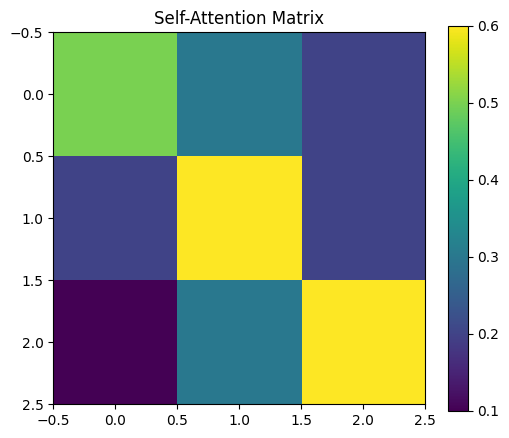

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(attention_matrix)

plt.colorbar()

plt.title("Self-Attention Matrix")

plt.show()

### Self-Attention Matrix 

This is a **heatmap showing attention relationships between all words**.

**What the graph shows:**
- **Rows**: Represent the current word being processed (position 0, 1, 2)
- **Columns**: Represent words being attended to (position 0, 1, 2)
- **Colors**: Yellow = high attention (value closer to 1), Dark Blue = low attention (value closer to 0)

**Example interpretation:**
- **Position [0,0] (top-left)**: Word attends to itself - very important (0.5)
- **Position [1,1] (center)**: Word attends to itself (0.6) - highest attention
- **Position [2,2] (bottom-right)**: Word attends to itself (0.6)
- **Position [0,1]**: Word 0 attends to Word 1 with weight 0.3
- **Position [1,2]**: Word 1 attends to Word 2 with weight 0.2

**Why this matters:**
This matrix is **fundamental to Transformers**. It shows how each word "looks at" every other word in the sequence. Each row sums to approximately 1 (like probabilities), showing the model's attention distribution for that position. This allows parallel processing instead of sequential RNN processing!

# Multi-Head Attention

Instead of using one attention mechanism, Transformers use multiple attention heads.

Each head learns different relationships.

Example:

Head 1:
Focuses on grammar

Head 2:
Focuses on subject-object relationships

Head 3:
Focuses on semantic meaning

Combining multiple heads improves understanding.

# Visualizing Multiple Attention Heads

In [6]:
import numpy as np

head1 = np.random.rand(5,5)
head2 = np.random.rand(5,5)
head3 = np.random.rand(5,5)
head4 = np.random.rand(5,5)

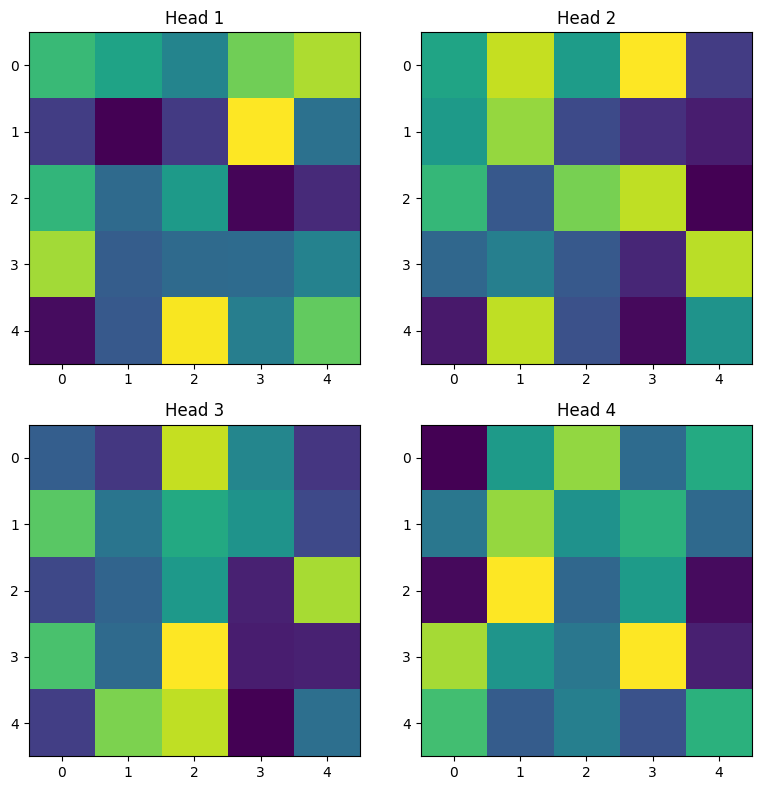

In [7]:
fig, axes = plt.subplots(2,2, figsize=(8,8))

axes[0,0].imshow(head1)
axes[0,0].set_title("Head 1")

axes[0,1].imshow(head2)
axes[0,1].set_title("Head 2")

axes[1,0].imshow(head3)
axes[1,0].set_title("Head 3")

axes[1,1].imshow(head4)
axes[1,1].set_title("Head 4")

plt.tight_layout()
plt.show()

### Four Attention Heads 

This shows **4 different attention heads from a single Transformer layer**.

**What the graph shows:**
- **4 separate heatmaps**: Head 1, Head 2, Head 3, Head 4 (2×2 grid)
- **Each heatmap**: A 5×5 matrix showing self-attention between 5 different positions
- **Color scale**: Yellow = high attention, Dark = low attention

**Key insight - Why Multiple Heads?**

Each head learns **different types of relationships**:

| Head | Typical Focus | Example |
|------|---------------|---------|
| Head 1 | Grammar/Structure | Subject-verb relationships |
| Head 2 | Semantic Meaning | Words with similar meanings |
| Head 3 | Positional Focus | Attending to nearby words |
| Head 4 | Long-range Dependencies | Words far apart in sequence |

**Why this matters:**
- **Single head limitation**: Would struggle to capture multiple relationship types simultaneously
- **Multi-head advantage**: Each head specializes, then outputs are combined (concatenated and projected)
- **BERT uses 12 heads** per layer × 12 layers = 144 different attention perspectives!
- This is why Transformers are so powerful - they can learn diverse linguistic phenomena in parallel

# Real Attention visualization

In [10]:
%pip install transformers torch

  Using cached transformers-5.10.2-py3-none-any.whl.metadata (33 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
Using cached transformers-5.10.2-py3-none-any.whl (11.0 MB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl (355 kB)

   ---------------------------------------- 0/3 [safetensors]
   ------------- -------------------------- 1/3 [tokenizers]
   ------------- -------------------------- 1/3 [tokenizers]
   -------------------------- ------------- 2/3 [transformers]
   -------------------------- ------------- 2/3 [transformers]
   -------------------------- ------------- 2/3 [transformers]
   -------------------------- ------------- 2/3 [transformers]
   -------------------------- ------------- 2/3 [transformers]
   -------------------------- ------------- 2/3 [transformers]
   -------------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from transformers import BertTokenizer, BertModel
import torch

c:\Users\lenevo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True
)

c:\Users\lenevo\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lenevo\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2280.51it/s]
[transformers] BertModel L

In [13]:
sentence = "The cat sat on the mat"

inputs = tokenizer(
    sentence,
    return_tensors="pt"
)

outputs = model(**inputs)

In [14]:
attentions = outputs.attentions

print(len(attentions))

12


because BERT Base has 12 layers.

In [15]:
first_layer = attentions[0]

print(first_layer.shape)

torch.Size([1, 12, 8, 8])


(batch_size, heads, tokens, tokens)

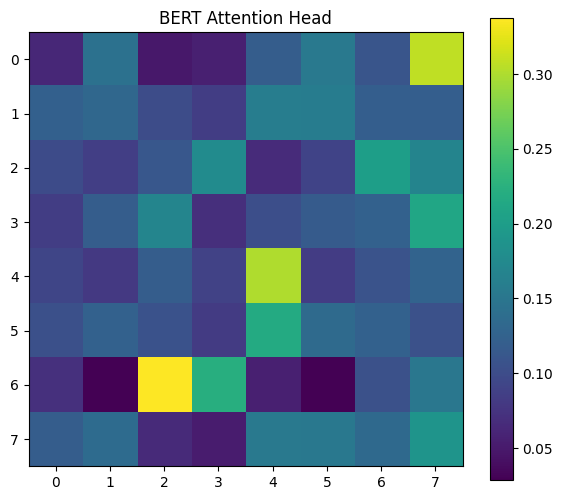

In [16]:
head = first_layer[0][0].detach().numpy()

plt.figure(figsize=(7,6))

plt.imshow(head)

plt.colorbar()

plt.title("BERT Attention Head")

plt.show()

### Real BERT Attention Head - What It Means

This is a **real attention matrix extracted from BERT's first layer**, processing "The cat sat on the mat".

**What the graph shows:**
- **Matrix size**: 8×8 (tokens including special tokens [CLS] and [SEP])
- **Rows**: Each token position (0-7)
- **Columns**: What each token attends to
- **Colors**: 
  - Yellow (bright) = **very high attention** (≈0.3)
  - Teal/Green = **medium attention** (≈0.2)
  - Dark purple = **very low attention** (≈0.05)

**Real-world observations from BERT:**
- **Token 4 (column 4)**: Has very bright yellow spots - heavily focused attention
- **Token 6 (column 6)**: Also shows strong attention patterns
- **Diagonal elements**: Some diagonal attention visible (words attending to themselves)
- **Off-diagonal patterns**: Complex patterns showing how tokens relate to each other

**Why this is different from simpler examples:**
- This is **real learned attention** from an actual pre-trained model
- Patterns are **learned from billions of tokens** (Wikipedia, BookCorpus)
- Much more complex than random or simple patterns
-  These patterns work because BERT was trained on real language data

**Important differences from our simple examples:**
- Simple examples: Clean, easy-to-understand patterns
- BERT attention: Complex, learned patterns that capture real linguistic phenomena we can't always easily interpret
- This shows why Transformers are so effective - they learn what to attend to from data!

# What I Learned

- Attention allows models to focus on important words.
- Query, Key, and Value form the foundation of attention.
- Self-attention enables direct interaction between all words.
- Multi-head attention captures different linguistic relationships.
- Transformers rely entirely on attention mechanisms.
- Modern NLP models such as BERT and GPT are built on Transformer architectures.